In [2]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.3 MB/s eta 0:00:06
   -- ------------------------------------- 0.5/8.1 MB 1.3 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.1 MB 1.2 MB/s eta 0:00:06
   ----- ---------------------------------- 1.0/8.1 MB 1.2 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.1 MB 1.2 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.1 MB 1.2 MB/s eta 0:00:06
   --------- ------------------------------ 1.8/8.1 MB 1.1 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.1 MB 1.2 MB/s eta 0:00:06
   ----------- ---------------------------- 2.4/8.1 MB 1.2 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.1 MB 1.2 MB/s eta 0:00:05
   ----------- -----------------------

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import koreanize_matplotlib

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
import matplotlib.font_manager as fm
import platform

font_path = "C:/Windows/Fonts/malgun.ttf" # 맑은 고딕 폰트 경로
font_prop = fm.FontProperties(fname=font_path)

In [ ]:
df_sample = pd.read_csv("./data/network_data.csv")
df_sample.head()

In [4]:
# 고객id : 고객 이름 매핑 딕셔너리 만들기
customer_dict = dict(zip(df_sample['고객ID'], df_sample['고객이름']))
customer_dict

{'C0116': '고객116',
 'C0169': '고객169',
 'C0086': '고객86',
 'C0104': '고객104',
 'C0126': '고객126',
 'C0184': '고객184',
 'C0181': '고객181',
 'C0154': '고객154',
 'C0081': '고객81',
 'C0199': '고객199',
 'C0149': '고객149',
 'C0058': '고객58',
 'C0042': '고객42',
 'C0187': '고객187',
 'C0176': '고객176',
 'C0107': '고객107',
 'C0177': '고객177',
 'C0027': '고객27',
 'C0144': '고객144',
 'C0072': '고객72',
 'C0123': '고객123',
 'C0132': '고객132',
 'C0005': '고객5',
 'C0140': '고객140',
 'C0048': '고객48',
 'C0049': '고객49',
 'C0114': '고객114',
 'C0138': '고객138',
 'C0045': '고객45',
 'C0031': '고객31',
 'C0078': '고객78',
 'C0164': '고객164',
 'C0047': '고객47',
 'C0028': '고객28',
 'C0089': '고객89',
 'C0119': '고객119',
 'C0170': '고객170',
 'C0150': '고객150',
 'C0004': '고객4',
 'C0093': '고객93',
 'C0069': '고객69',
 'C0180': '고객180',
 'C0143': '고객143',
 'C0021': '고객21',
 'C0030': '고객30',
 'C0200': '고객200',
 'C0139': '고객139',
 'C0092': '고객92',
 'C0159': '고객159',
 'C0088': '고객88',
 'C0195': '고객195',
 'C0076': '고객76',
 'C0053': '고객53',
 'C0033': '고객33',
 

In [17]:
# 고객 네트워크 그래프 생성
G = nx.Graph()

for _, row in df_sample.iterrows():
    cust_id = row['고객ID']
    cust_name = row['고객이름']
    cust_label = f"{cust_name} ({cust_id})"
    
    companion_id = row['동반인ID']
    if pd.notnull(companion_id):
        companion_name = customer_dict.get(companion_id, companion_id)
        companion_label = f"{companion_name} ({companion_id})"
        
        G.add_node(cust_label)
        G.add_node(companion_label)
        G.add_edge(cust_label, companion_label)
        


In [18]:
# 중심성 분석
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)



In [22]:
sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

[('고객106 (C0106)', 0.05154639175257732),
 ('고객133 (C0133)', 0.04639175257731959),
 ('고객153 (C0153)', 0.041237113402061855),
 ('고객163 (C0163)', 0.041237113402061855),
 ('고객100 (C0100)', 0.041237113402061855),
 ('고객114 (C0114)', 0.041237113402061855),
 ('고객195 (C0195)', 0.041237113402061855),
 ('고객24 (C0024)', 0.03608247422680412),
 ('고객170 (C0170)', 0.03608247422680412),
 ('고객183 (C0183)', 0.03608247422680412)]

In [23]:
# 상위 10명 정리
top_k = 10
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:top_k]

result = []
for node, degree in top_degree:
    result.append({
        "고객이름(고객ID)" : node,
        "연결중심성(Degree)" : round(degree, 4),
        "매개중심성(Betweenness)" : round(betweenness_centrality.get(node, 0), 4),
        "근접중심성(Closeness)" : round(closeness_centrality.get(node, 0), 4)
    })
    
df_result = pd.DataFrame(result)
df_result

,고객이름(고객ID),연결중심성(Degree),매개중심성(Betweenness),근접중심성(Closeness)
0,고객106 (C0106),0.0515,0.0713,0.3050
1,고객133 (C0133),0.0464,0.0645,0.3065
2,고객153 (C0153),0.0412,0.0440,0.2840
3,고객163 (C0163),0.0412,0.0366,0.2904
4,고객100 (C0100),0.0412,0.0531,0.2953
5,고객114 (C0114),0.0412,0.0517,0.2900
6,고객195 (C0195),0.0412,0.0707,0.3031
7,고객24 (C0024),0.0361,0.0412,0.2866
8,고객170 (C0170),0.0361,0.0331,0.2771
9,고객183 (C0183),0.0361,0.0375,0.2870


* 연결중심성(Degree): 직접 연결된 고객 수 비율, 동반 방문 횟수나 연결된 고객이 많을수록 높음
* 매개중심성(Betweenness): 다른 고객 사이의 중개 역할 비율, 다양한 고객 집단을 이어주는 다리 역할을 할수록 높음
* 근접 중심성(Closeness): 전체 고객들과의 거리 평균의 역수, 네트워크 전체와 가깝게 연결되어 있을 수록 높음.

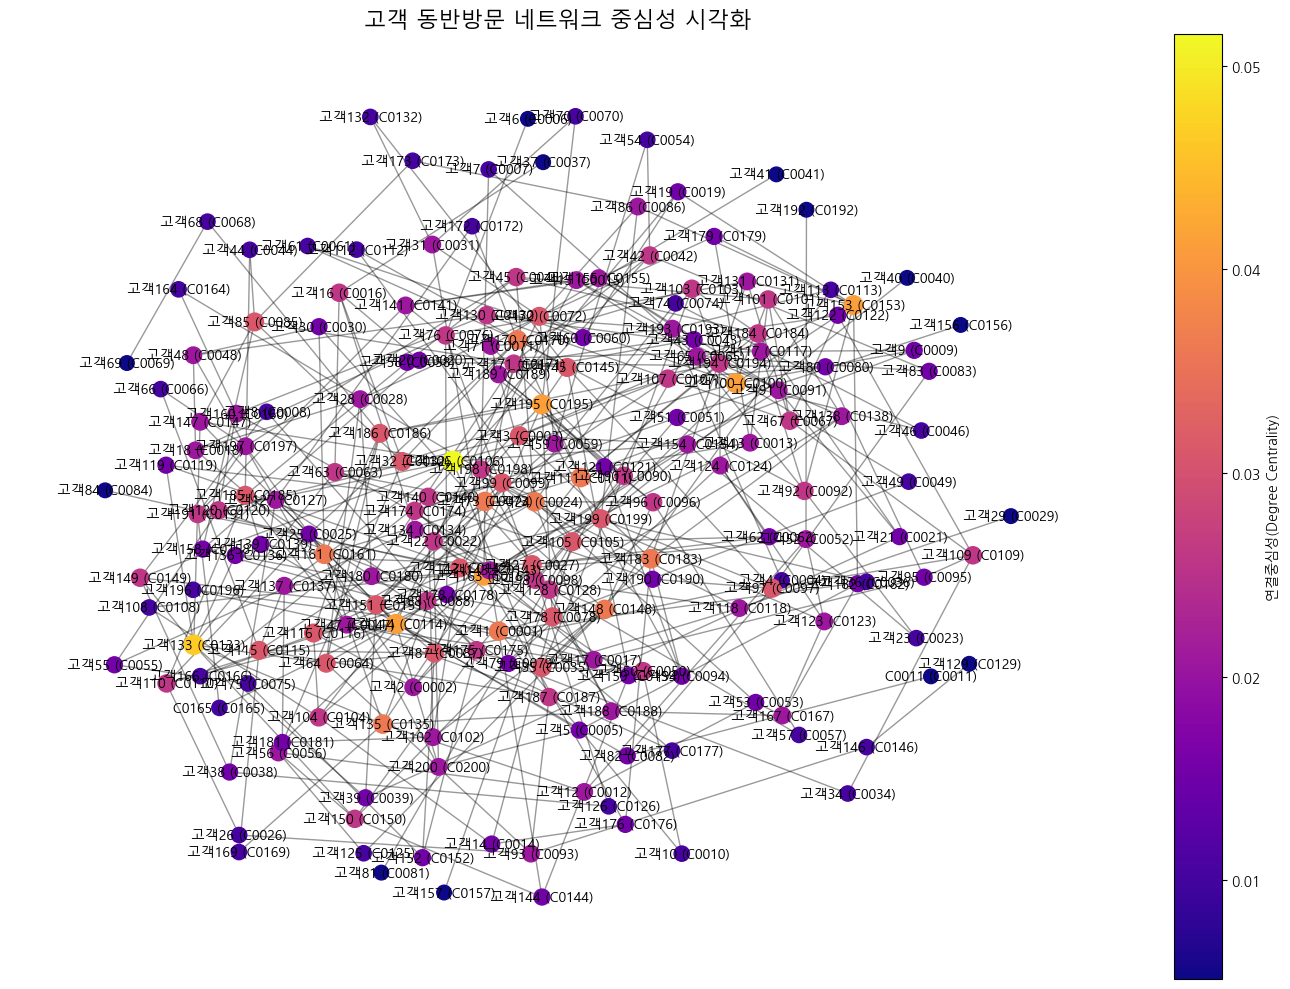

In [27]:
plt.rcParams['axes.unicode_minus'] = False

# 노드 속성 설정
node_colors = [degree_centrality.get(node, 0) for node in G.nodes]
node_sizes = [2000 * degree_centrality.get(node, 0) + 100 for node in G.nodes]

# 노드 위치 계산 k는 노드간의 평균거리(작으면 촘촘하게, 크면 넓게)
pos = nx.spring_layout(G, seed=42, k=0.5)

plt.figure(figsize=(14,10))
nodes = nx.draw_networkx_nodes(
        G, pos,
        node_color = node_colors,
        node_size = node_sizes,
        cmap = plt.cm.plasma
        )

# 엣지와 레이블
nx.draw_networkx_edges(G, pos, alpha=0.4)
nx.draw_networkx_labels(G, pos, font_size=10, font_family=font_prop.get_name())
plt.colorbar(nodes, label="연결중심성(Degree Centrality)")
plt.title("고객 동반방문 네트워크 중심성 시각화", fontproperties = font_prop, fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()